In [2]:
"""
Sigma(E) and M(E) Non-Hermiticity Analysis with respect to condition numbers
===================================
Loads Sigma matrices for indices 95-105, computes non-Hermiticity metrics,
and plots how they evolve across energy index.
Run cell by cell in Jupyter.
"""

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------

folder = Path("/scratch/yimili/matrices")
name       = "carbon-nanotube"   # <-- change to "carbon-chain" or "carbon-nanotube"
indices    = list(range(0, 402))  # 95 to 105 inclusive
idx_arr = np.array(indices)

offset2 = 0.005
res = 0.005

energies = -4.6 - offset2 + res*idx_arr.astype(float)


In [3]:
H = np.load(folder / name / f"H_even.npy")
S = np.load(folder / name / f"S_even.npy")

max_singular_values_even = np.load(folder / name / "max_singular_values_even.npy")
max_singular_values_uneven = np.load(folder / name / "max_singular_values_uneven.npy")
min_singular_values_even = np.load(folder / name / "min_singular_values_even.npy")
min_singular_values_uneven = np.load(folder / name / "min_singular_values_uneven.npy")

max_singular_values = np.empty(len(max_singular_values_even) + len(max_singular_values_uneven), dtype=max_singular_values_even.dtype)
max_singular_values[0::2] = max_singular_values_even
max_singular_values[1::2] = max_singular_values_uneven

min_singular_values = np.empty(len(min_singular_values_even) + len(min_singular_values_uneven), dtype=min_singular_values_even.dtype)
min_singular_values[0::2] = min_singular_values_even
min_singular_values[1::2] = min_singular_values_uneven

condition_numbers = max_singular_values/min_singular_values

kappa_even = np.load(folder / name / "condition_full_svd_even.npy")
kappa_uneven = np.load(folder / name / "condition_full_svd_uneven.npy")
kappa = np.empty(len(kappa_even) + len(kappa_uneven), dtype=kappa_even.dtype)

kappa[0::2] = kappa_even
kappa[1::2] = kappa_uneven

# ---------------------------------------------------------------------------
# Load all M(E) matrices
# ---------------------------------------------------------------------------
M = {}
for idx in indices:
    path = folder / name / f"M_E_{idx}.npy"
    M[idx] = np.load(path)

# ---------------------------------------------------------------------------
# Load all Sigma(E) matrices
# ---------------------------------------------------------------------------
Sig = {}
for idx in indices:
    path = folder / name / f"Sigma_E_{idx}.npy"
    Sig[idx] = np.load(path)
    
# ---------------------------------------------------------------------------
# Load all rhs(E) matrices
# ---------------------------------------------------------------------------
rhs = {}
for idx in indices:
    path = folder / name / f"rhs_E_{idx}.npy"
    rhs[idx] = np.load(path)

# ---------------------------------------------------------------------------
# Load all spectrum(E) matrices
# ---------------------------------------------------------------------------
w = {}
for idx in indices:
    path = folder / name / f"spectrum_M_E_{idx}.npy"
    w[idx] = np.load(path)

M_arr   = np.array([M[idx]   for idx in indices])
Sig_arr = np.array([Sig[idx] for idx in indices])
#rhs_arr = np.array([rhs[idx] for idx in indices])
w_arr   = np.array([w[idx]   for idx in indices])

Sigma_arr_left = Sig_arr[:, :32, :32]
Sigma_arr_right = Sig_arr[:, -32:, -32:]

print(M_arr.shape)    # (n_energies, n, n)
print(Sig_arr.shape)    # (n_energies, n, n)
#print(rhs_arr.shape)  # (n_energies, n) or (n_energies, n, k)
print(w_arr.shape)    # (n_energies, n)

(402, 768, 768)
(402, 768, 768)
(402, 768)


In [4]:
# ---------------------------------------------------------------------------
# Helper: compute all metrics
# ---------------------------------------------------------------------------
def hermitian_metrics(A):
    frob_A = np.linalg.norm(A, 'fro')
    n = A.shape[0]
    Ah = A.conj().T
    # Hermitian and anti-Hermitian parts
    H_part  = (A + Ah) / 2          # Hermitian part  (real energy shift)
    K_part  = (A - Ah) / (2j)       # anti-Hermitian part, also Hermitian matrix
    # 1. Max absolute deviation from Hermitian
    diff         = A - Ah
    max_dev      = np.max(np.abs(diff))
    rel_dev      = max_dev / (frob_A + 1e-300)
    # 2. Frobenius norm of anti-Hermitian part
    frob_antiherm = np.linalg.norm(diff, 'fro') / 2
    # 2b. Diagonal contribution to anti-Hermiticity
    diag_antiherm      = np.diag(np.diag(diff) / 2)
    frob_diag_antiherm = np.linalg.norm(diag_antiherm, 'fro')
    diag_ratio         = frob_diag_antiherm / (frob_antiherm + 1e-300)
    # 3. Eigenvalues of A itself (+ eigenvectors for kappa_V)
    w_A, V_A     = np.linalg.eig(A) #!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!EXPENSIVE!!!!!!!!!!!!!!!!!!!!
    # 3b. imaginary parts of the eigenvalues
    min_abs_A_imag    = np.min(np.abs(w_A.imag))
    max_abs_A_imag    = np.max(np.abs(w_A.imag))
    # 3c. Eigenvector condition number  (non-normality / pseudospectrum diagnostic)
    kappa_V      = np.linalg.cond(V_A)
    # 3d. Henrici's departure from normality (basis-independent)
    dep_norm     = np.sqrt(max(frob_A**2 - np.sum(np.abs(w_A)**2), 0.0))
    dep_norm_rel = dep_norm / (frob_A + 1e-300)
    # 3e. Smallest |eigenvalue|  (upper bound on σ_min; combined with stored σ_min downstream)
    min_abs_eig  = np.min(np.abs(w_A))
    # 4. Eigenvalues of K (the broadening operator) — these are the Lorentzian widths
    w_K          = np.zeros(K_part.shape[0], dtype=complex)
    min_abs_K    = np.min(np.abs(w_K))
    max_abs_K    = np.max(np.abs(w_K))
    # 5. Eigenvalues of H (the real energy shift)
    w_H          = np.zeros(H_part.shape[0], dtype=complex)
    min_abs_H    = np.min(np.abs(w_H))
    max_abs_H    = np.max(np.abs(w_H))
    # 6. Non-normality: ||AA† - A†A||_F  (zero iff A is normal)
    comm         = A @ Ah - Ah @ A
    non_normality = np.linalg.norm(comm, 'fro') / (frob_A**2 + 1e-300)
    # 7. Ratio of anti-Hermitian to Hermitian spectral weight
    norm_H       = np.linalg.norm(H_part, 'fro')
    norm_K       = np.linalg.norm(K_part, 'fro')
    ratio_KH     = norm_K / (norm_H + 1e-300)
    
    return {
        "frob_A":             frob_A,
        "max_dev":            max_dev,
        "rel_dev":            rel_dev,
        "frob_antiherm":      frob_antiherm,
        "frob_diag_antiherm": frob_diag_antiherm,
        "diag_ratio":         diag_ratio,
        "w_A":                w_A,
        "min_abs_A_imag":     min_abs_A_imag,
        "max_abs_A_imag":     max_abs_A_imag,
        "kappa_V":            kappa_V,
        "dep_norm":           dep_norm,
        "dep_norm_rel":       dep_norm_rel,
        "min_abs_eig":        min_abs_eig,
        "w_K":                w_K,
        "min_abs_K":          min_abs_K,
        "max_abs_K":          max_abs_K,
        "w_H":                w_H,
        "min_abs_H":          min_abs_H,
        "max_abs_H":          max_abs_H,
        "non_normality":      non_normality,
        "norm_H":             norm_H,
        "norm_K":             norm_K,
        "ratio_KH":           ratio_KH,
        "H_part":             H_part,
        "K_part":             K_part,
    }

In [5]:
def plot_metrics(metrics_dict, indices, energies, idx_arr, name, filename=None):
    min_abs_eig_arr = np.array([metrics_dict[i]["min_abs_eig"] for i in indices])

    fig, axes = plt.subplots(6, 2, figsize=(12, 26))
    fig.suptitle(f"Non-Hermiticity metrics — {name}", fontsize=13)

    def _plot(ax, values, ylabel, title, logy=True):
        ax.plot(energies, values, "o-")
        ax.axvline(-3.6, color="red", linestyle="--", label="Conduction band edge")
        ax.set_title(title)
        ax.set_xlabel("Energy (eV)")
        ax.set_ylabel(ylabel)
        if logy and np.all(np.array(values) > 0):
            ax.set_yscale("log")
        ax.grid(True)
        ax2 = ax.twiny()
        ax2.set_xlim(ax.get_xlim())
        tick_energies = energies[::len(energies)//6]
        tick_indices  = idx_arr[::len(idx_arr)//6]
        ax2.set_xticks(tick_energies)
        ax2.set_xticklabels(tick_indices)
        ax2.set_xlabel("Index")
        ax2.xaxis.set_label_position("bottom")
        ax2.xaxis.tick_bottom()
        ax2.spines["bottom"].set_position(("outward", 30))

    _plot(axes[0, 0], [metrics_dict[i]["frob_A"]         for i in indices], "", "‖A‖_F")
    _plot(axes[0, 1], [metrics_dict[i]["max_dev"]        for i in indices], "", "Max |A - A†|")
    _plot(axes[1, 0], [metrics_dict[i]["rel_dev"]        for i in indices], "", "Relative deviation")
    _plot(axes[1, 1], [metrics_dict[i]["frob_antiherm"]  for i in indices], "", "‖anti-Herm part‖_F")
    _plot(axes[2, 0], [metrics_dict[i]["diag_ratio"]     for i in indices], "", "Diag / ‖anti-Herm‖_F", logy=False)
    _plot(axes[2, 1], [metrics_dict[i]["min_abs_A_imag"] for i in indices], "eV", "min |eig(A).imag|  ← Lorentzian floor")
    _plot(axes[3, 0], [metrics_dict[i]["non_normality"]  for i in indices], "", "Non-normality ‖AA†-A†A‖_F / ‖A‖²_F")
    _plot(axes[3, 1], [metrics_dict[i]["ratio_KH"]       for i in indices], "", "‖K‖_F / ‖H‖_F")
    _plot(axes[4, 0], [metrics_dict[i]["kappa_V"]        for i in indices], "", "κ(V)  ← eigenvector cond. (worst case)")
    _plot(axes[4, 1], [metrics_dict[i]["dep_norm_rel"]   for i in indices], "", "Henrici dep / ‖A‖_F", logy=False)
    _plot(axes[5, 0], min_abs_eig_arr,                                      "", "min |eig(A)|  (upper bound on σ_min)")
    axes[5, 1].set_visible(False)

    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()

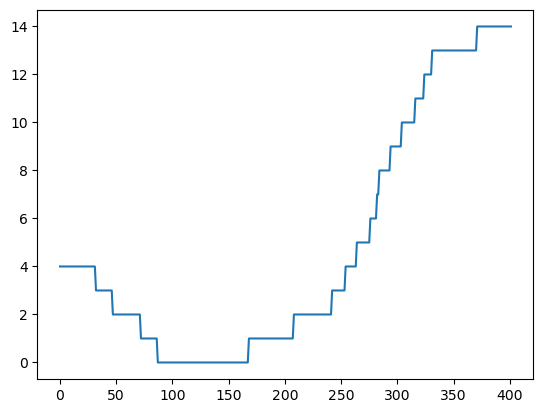

In [6]:
plt.plot(idx_arr, [rhs[idx].shape[-1] for idx in idx_arr])
plt.savefig("rhs_shape[-1].png", dpi=150, bbox_inches="tight")

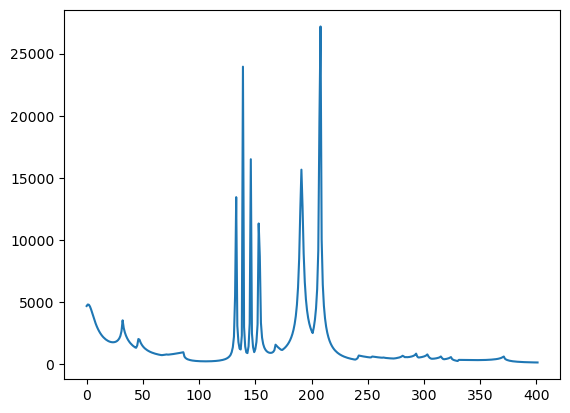

In [7]:
plt.plot(idx_arr, kappa)

In [8]:
# ---------------------------------------------------------------------------
# Compute metrics for all indices
# ---------------------------------------------------------------------------

metrics_sigma_left = {idx: hermitian_metrics(Sigma_arr_left[idx]) for idx in indices}
metrics_sigma_right = {idx: hermitian_metrics(Sigma_arr_right[idx]) for idx in indices}


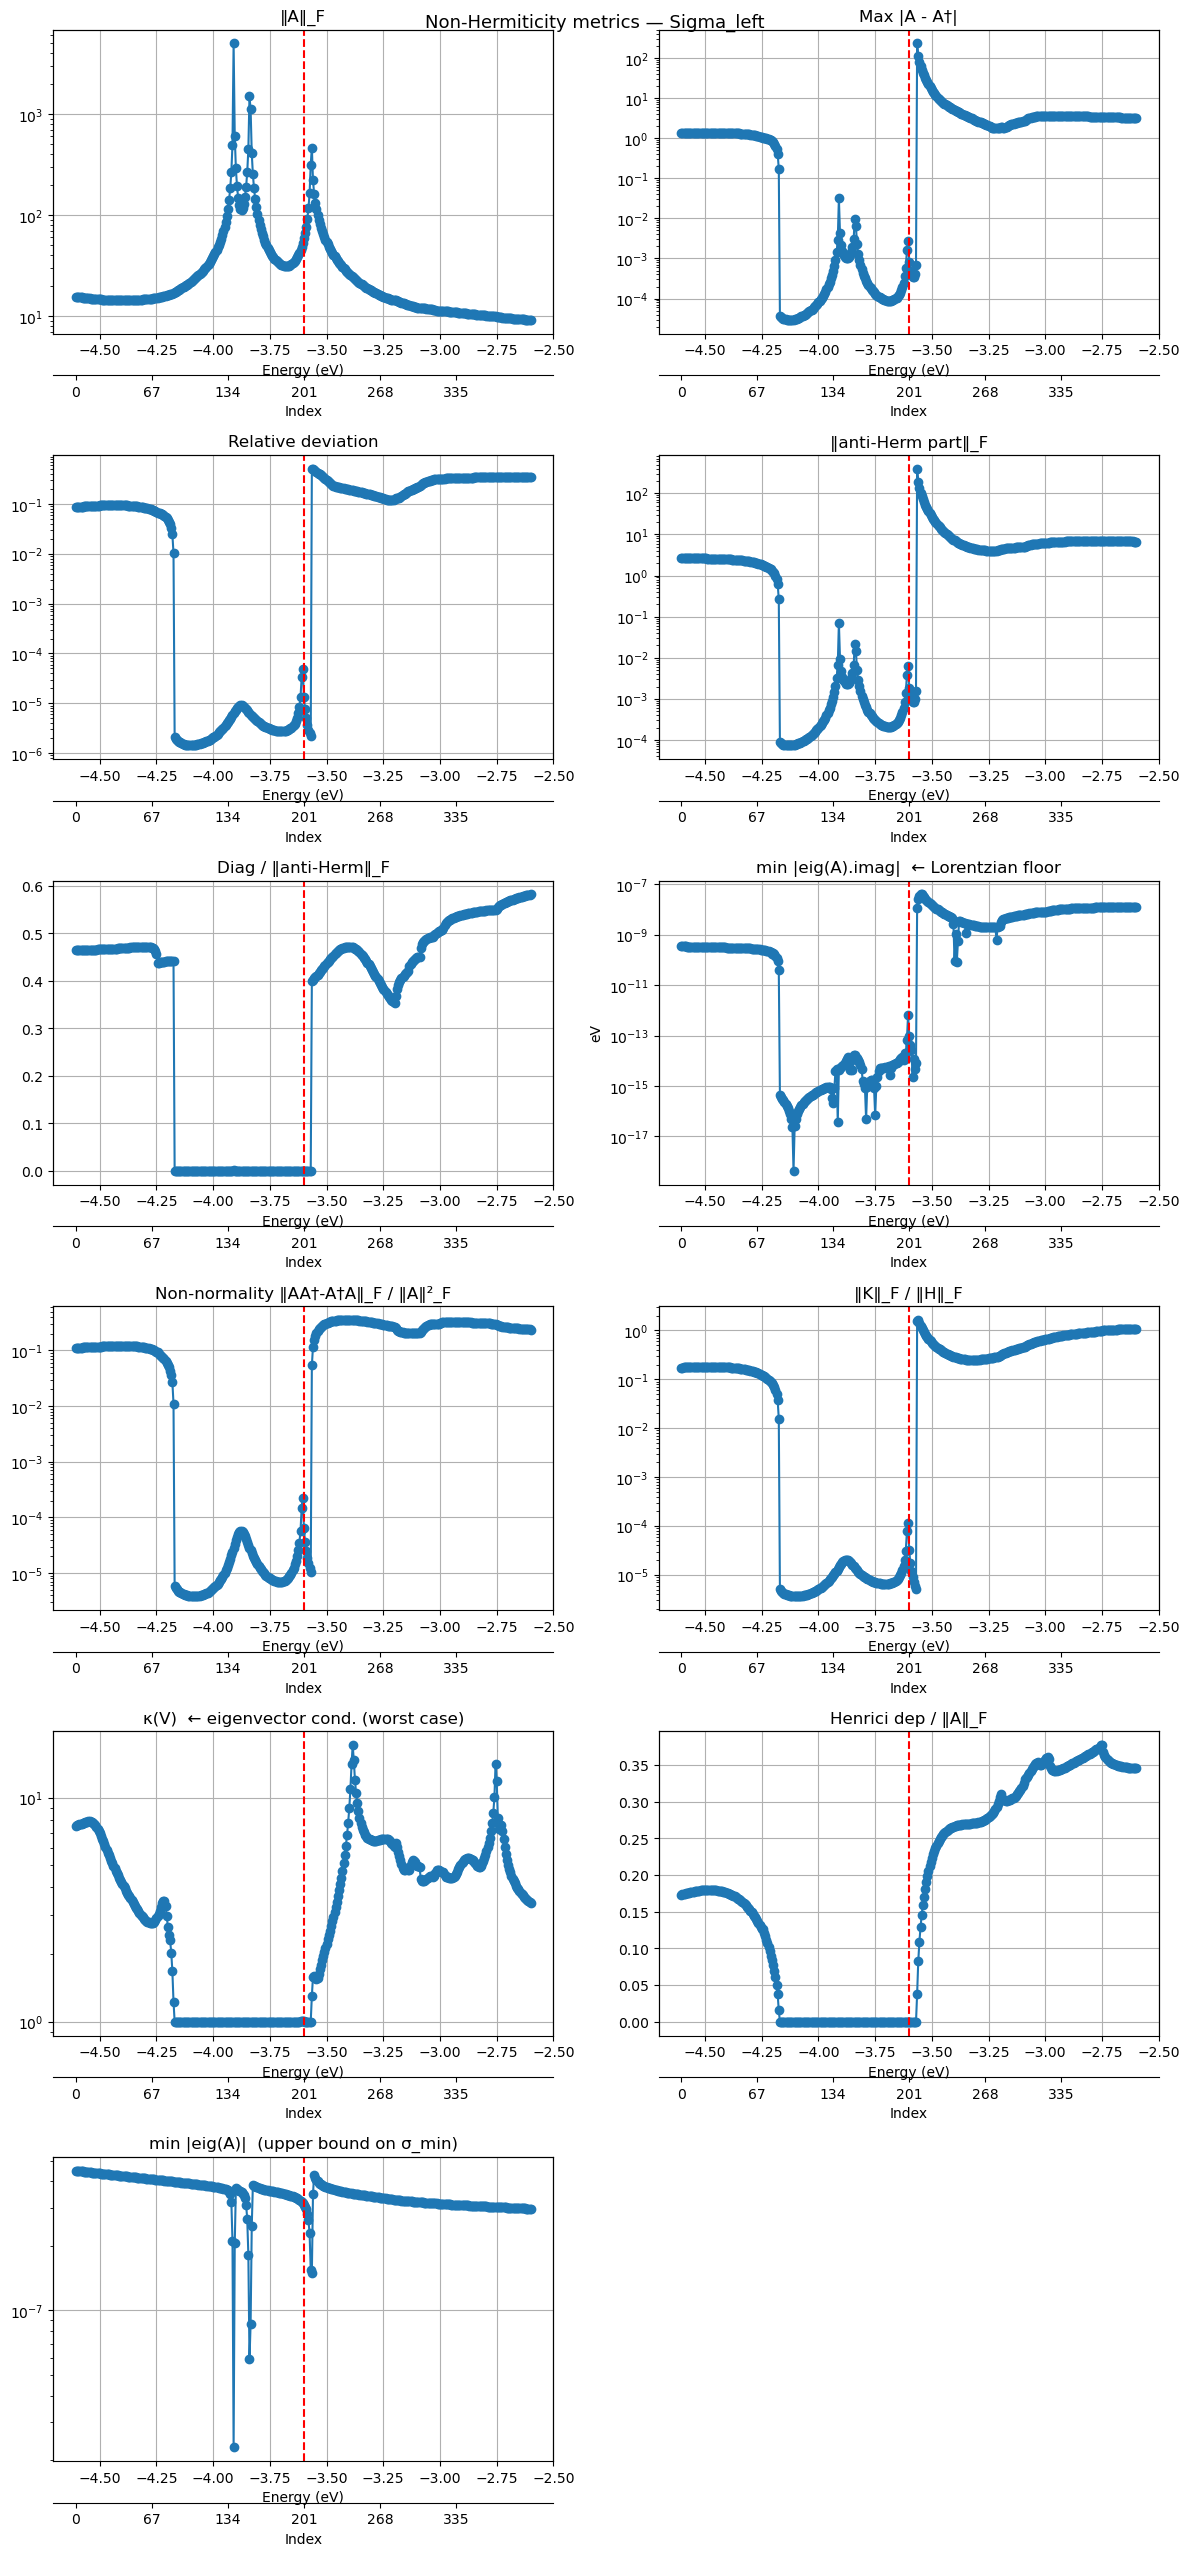

In [9]:
plot_metrics(metrics_sigma_left, indices, energies, idx_arr, "Sigma_left",
             filename=f"metrics_sigma_left_{name}.png")

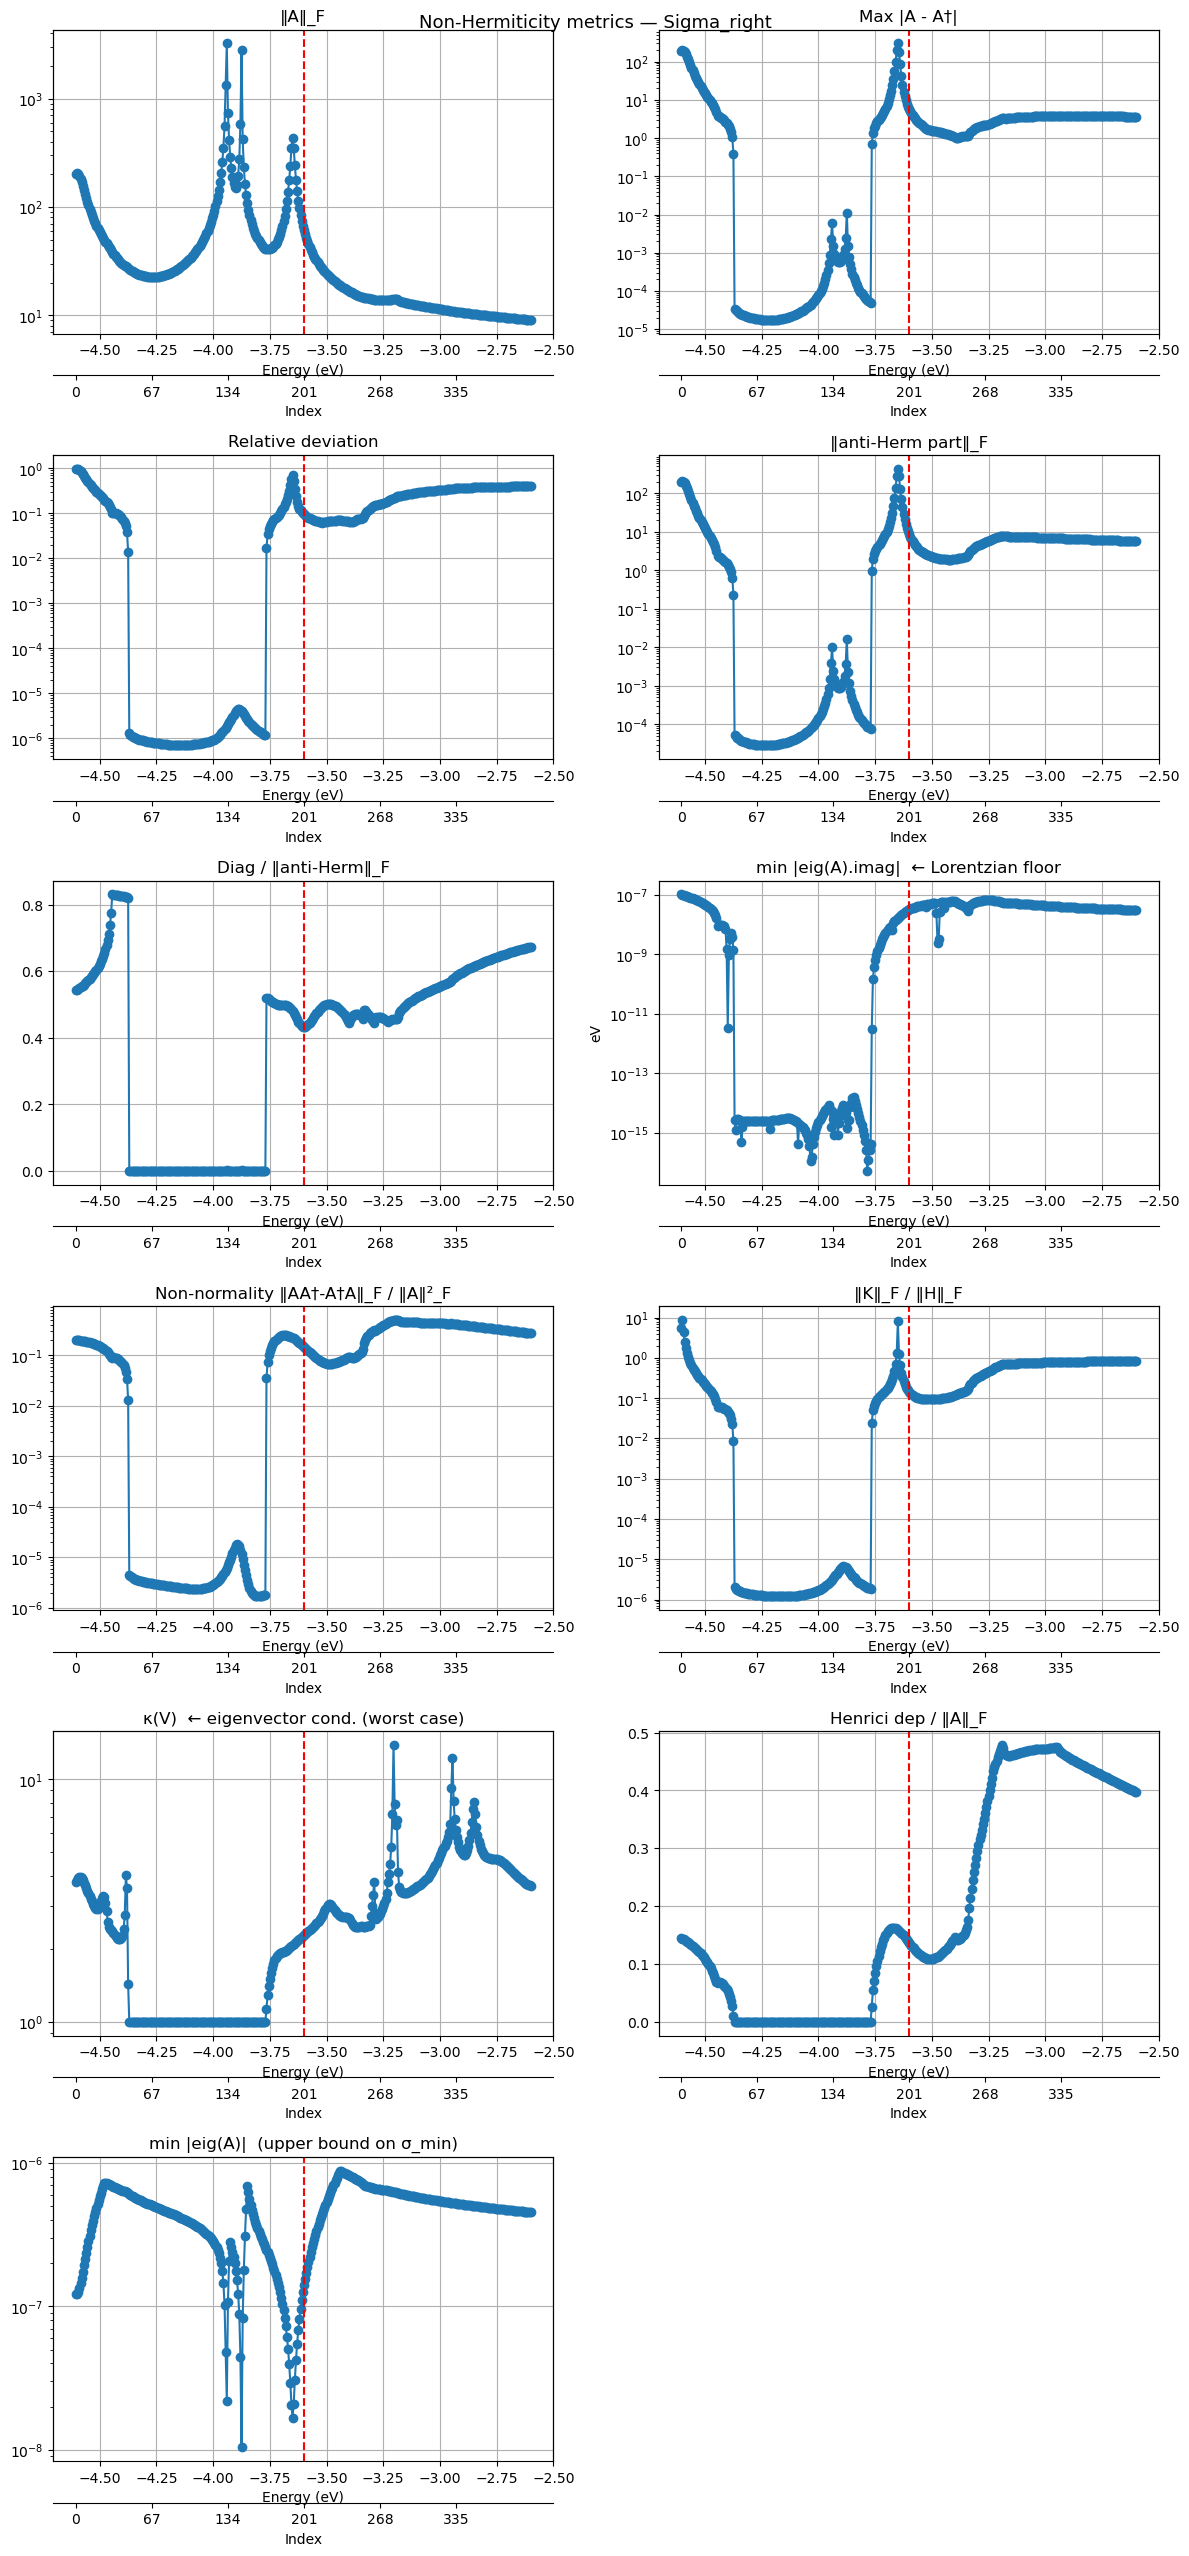

In [10]:
plot_metrics(metrics_sigma_right, indices, energies, idx_arr, "Sigma_right",
             filename=f"metrics_sigma_right_{name}.png")

0.0703125
0.009765625


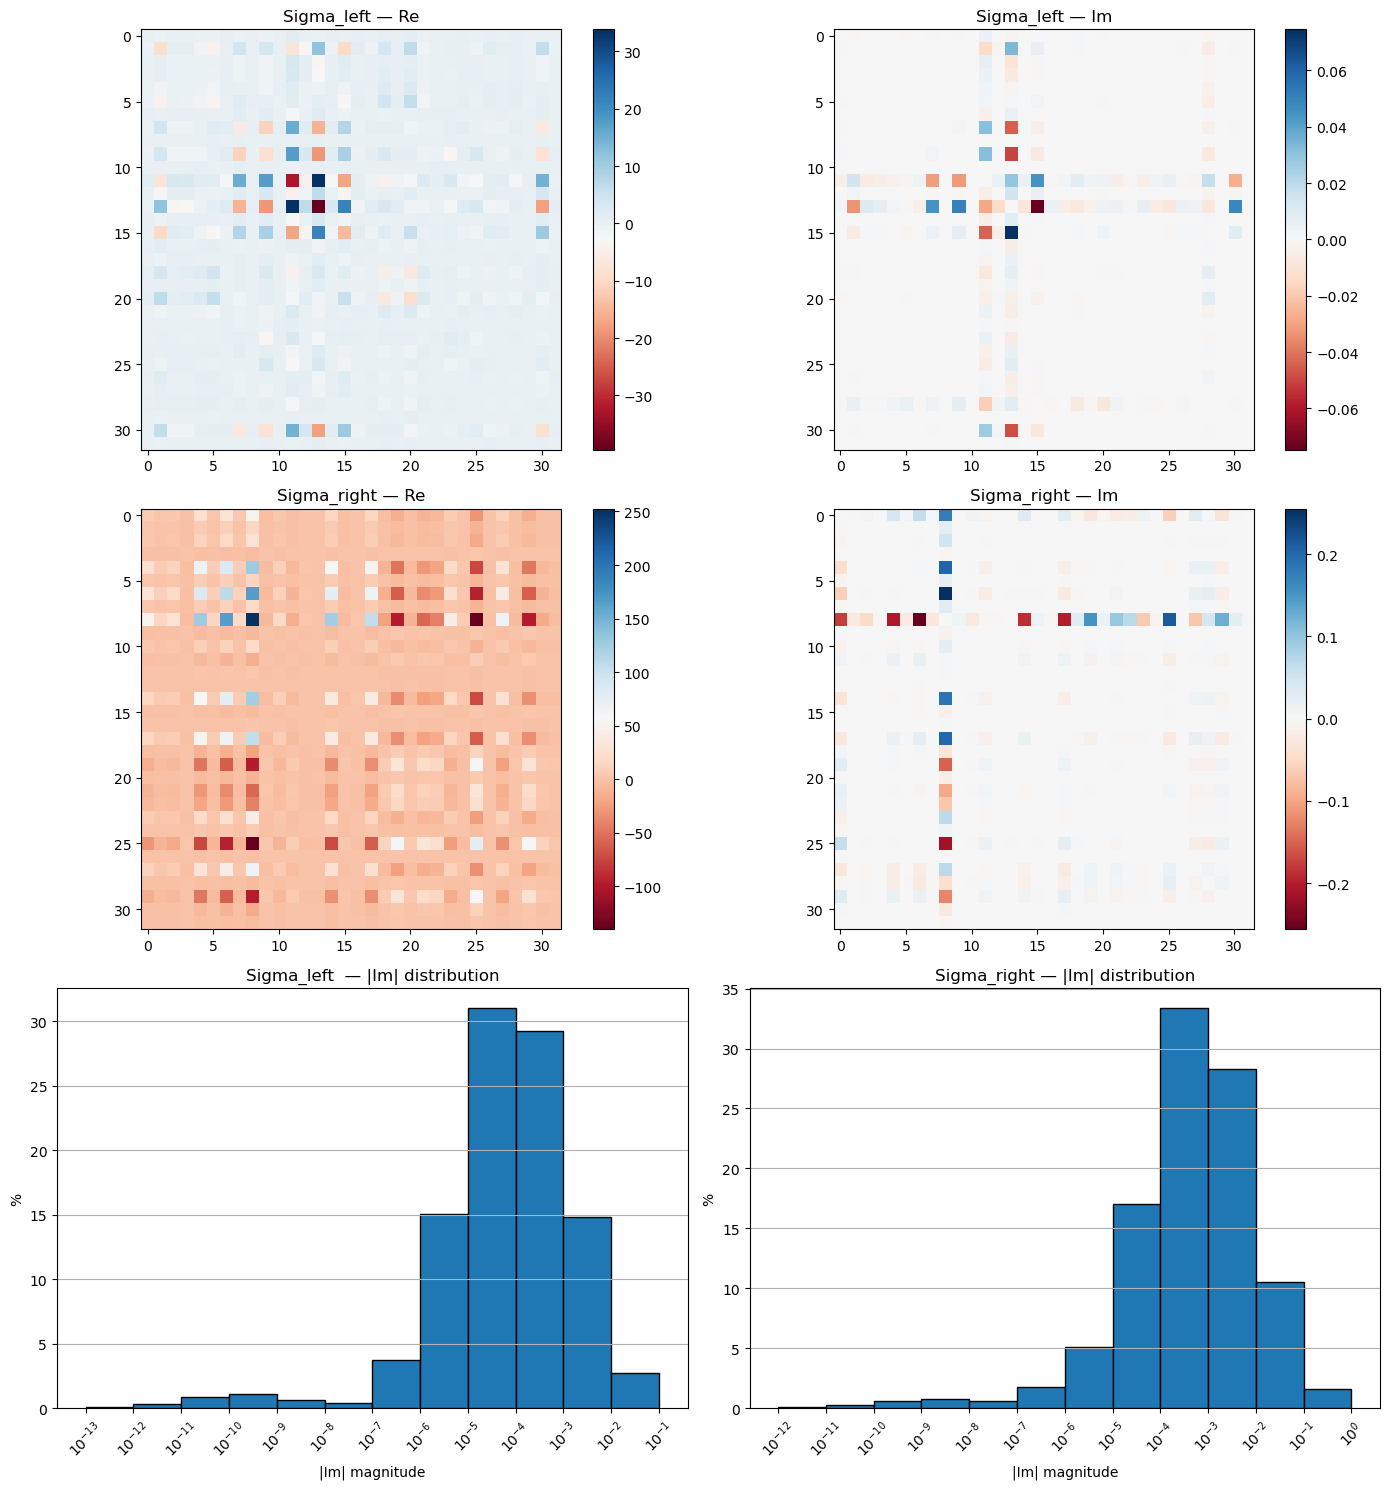

In [11]:
i = 134
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

im00 = axes[0, 0].imshow(Sigma_arr_left[i].real,  cmap="RdBu")
im01 = axes[0, 1].imshow(Sigma_arr_left[i].imag,  cmap="RdBu")
im10 = axes[1, 0].imshow(Sigma_arr_right[i].real, cmap="RdBu")
im11 = axes[1, 1].imshow(Sigma_arr_right[i].imag, cmap="RdBu")

axes[0, 0].set_title("Sigma_left — Re")
axes[0, 1].set_title("Sigma_left — Im")
axes[1, 0].set_title("Sigma_right — Re")
axes[1, 1].set_title("Sigma_right — Im")

for ax, im in zip(axes[:2].flat, [im00, im01, im10, im11]):
    fig.colorbar(im, ax=ax)

# Log-magnitude distribution of imaginary entries
def plot_logmag_hist(ax, data, title):
    flat = np.abs(data.imag).flatten()
    flat = flat[flat > 0]
    log_vals = np.log10(flat)
    bins = np.arange(np.floor(log_vals.min()), np.ceil(log_vals.max()) + 1)
    weights = np.ones(len(log_vals)) / data.size * 100   # % of all non-zero entries
    ax.hist(log_vals, bins=bins, weights=weights, edgecolor='black')
    ax.set_xticks(bins)
    ax.set_xticklabels([f"$10^{{{int(b)}}}$" for b in bins], rotation=45)
    ax.set_xlabel("|Im| magnitude")
    ax.set_ylabel("%")
    ax.set_title(title)
    ax.grid(True, axis='y')

plot_logmag_hist(axes[2, 0], Sigma_arr_left[i],  "Sigma_left  — |Im| distribution")
plot_logmag_hist(axes[2, 1], Sigma_arr_right[i], "Sigma_right — |Im| distribution")

print(np.sum(np.abs(Sigma_arr_left[i].imag)  < 1e-6)  / Sigma_arr_left[i].size)
print(np.sum(np.abs(Sigma_arr_right[i].imag) < 1e-9) / Sigma_arr_right[i].size)

plt.tight_layout()

In [12]:
##################### Frobenius norms ###################

In [13]:
# ---------------------------------------------------------------------------
# Precompute norms
# ---------------------------------------------------------------------------
norm_H   = np.linalg.norm(H, 'fro')
norm_S   = np.linalg.norm(S, 'fro')
norm_M   = np.array([np.linalg.norm(M[i], 'fro')               for i in indices])
norm_sig = np.array([np.linalg.norm(Sig[i], 'fro')             for i in indices])
norm_SL  = np.array([np.linalg.norm(Sigma_arr_left[i], 'fro')  for i in indices])
norm_SR  = np.array([np.linalg.norm(Sigma_arr_right[i], 'fro') for i in indices])
upper_bound = norm_H + np.abs(energies) * norm_S + norm_SL + norm_SR

n = Sig[0].shape[0]

def embed(small, n, position='top-left'):
    large = np.zeros((n, n), dtype=small.dtype)
    m = small.shape[0]
    if position == 'top-left':
        large[:m, :m] = small
    elif position == 'bottom-right':
        large[-m:, -m:] = small
    return large

# ---------------------------------------------------------------------------
# 4x2 grid: individual norms
# ---------------------------------------------------------------------------
# ... rest of your code

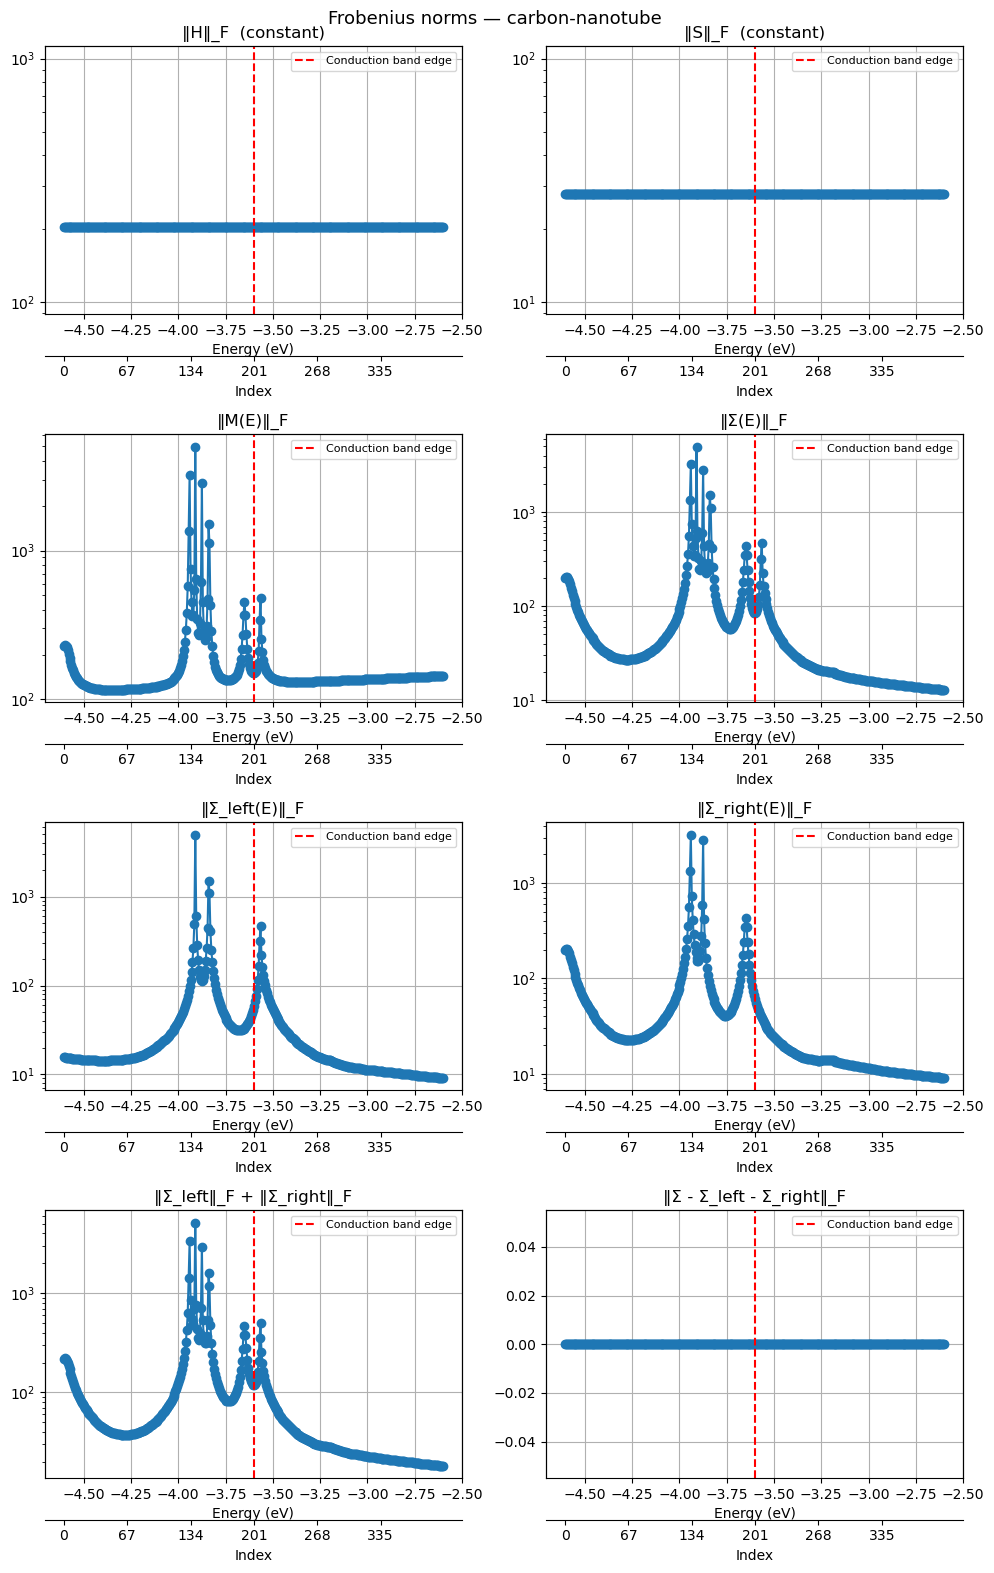

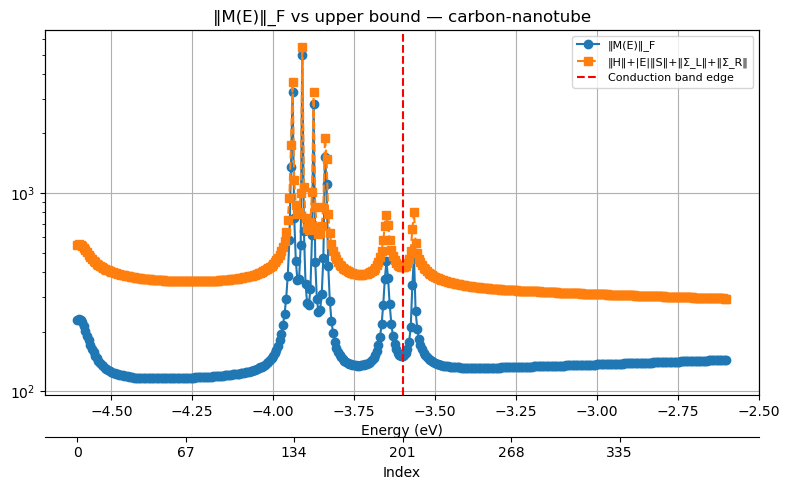

In [14]:
# ---------------------------------------------------------------------------
# 2x4 grid: individual norms
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(4, 2, figsize=(10, 16))
fig.suptitle(f"Frobenius norms — {name}", fontsize=13)

def _plot(ax, values, title, logy=True):
    ax.plot(energies, values, "o-")
    ax.axvline(-3.6, color="red", linestyle="--", label="Conduction band edge")
    ax.set_title(title)
    ax.set_xlabel("Energy (eV)")
    if logy and np.all(np.array(values) > 0):
        ax.set_yscale("log")
    ax.grid(True)
    ax.legend(fontsize=8)
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    tick_energies = energies[::len(energies)//6]
    tick_indices  = idx_arr[::len(idx_arr)//6]
    ax2.set_xticks(tick_energies)
    ax2.set_xticklabels(tick_indices)
    ax2.set_xlabel("Index")
    ax2.xaxis.set_label_position("bottom")
    ax2.xaxis.tick_bottom()
    ax2.spines["bottom"].set_position(("outward", 30))

_plot(axes[0, 0], np.full(len(energies), norm_H),  "‖H‖_F  (constant)")
_plot(axes[0, 1], np.full(len(energies), norm_S),  "‖S‖_F  (constant)")
_plot(axes[1, 0], norm_M,                          "‖M(E)‖_F")
_plot(axes[1, 1], norm_sig,                        "‖Σ(E)‖_F")
_plot(axes[2, 0], norm_SL,                         "‖Σ_left(E)‖_F")
_plot(axes[2, 1], norm_SR,                         "‖Σ_right(E)‖_F")
_plot(axes[3, 0], norm_SL + norm_SR,               "‖Σ_left‖_F + ‖Σ_right‖_F")
_plot(axes[3, 1], [
    np.linalg.norm(
        Sig[i] - embed(Sigma_arr_left[i], n, 'top-left') - embed(Sigma_arr_right[i], n, 'bottom-right'),
        'fro')
    for i in indices],                             "‖Σ - Σ_left - Σ_right‖_F")

plt.tight_layout()
plt.savefig(f"frobenius_norms_{name}.png", dpi=150, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------------------------
# Separate: M(E) norm vs upper bound
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(energies, norm_M,      "o-",          label="‖M(E)‖_F")
ax.plot(energies, upper_bound, "s--", color="tab:orange",
        label="‖H‖+|E|‖S‖+‖Σ_L‖+‖Σ_R‖")
ax.axvline(-3.6, color="red", linestyle="--", label="Conduction band edge")
ax.set_title(f"‖M(E)‖_F vs upper bound — {name}")
ax.set_xlabel("Energy (eV)")
ax.set_yscale("log")
ax.grid(True)
ax.legend(fontsize=8)
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
tick_energies = energies[::len(energies)//6]
tick_indices  = idx_arr[::len(idx_arr)//6]
ax2.set_xticks(tick_energies)
ax2.set_xticklabels(tick_indices)
ax2.set_xlabel("Index")
ax2.xaxis.set_label_position("bottom")
ax2.xaxis.tick_bottom()
ax2.spines["bottom"].set_position(("outward", 30))
plt.tight_layout()
plt.savefig(f"frobenius_norm_bound_{name}.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
###################### Minimum singular value through smallest eigenvalue magnitude ##################

In [16]:
from scipy.sparse.linalg import eigs
import scipy.sparse as sp

def min_abs_eig_sparse(A_dense, tol=1e-6):
    A_sp = sp.csc_matrix(A_dense)
    try:
        vals = eigs(A_sp, k=1, sigma=0.0, which='LM',
                    tol=tol, return_eigenvectors=False)
        return np.abs(vals[0])
    except Exception:
        return np.min(np.abs(np.linalg.eigvals(A_dense)))

min_abs_eig_arr = np.array([min_abs_eig_sparse(M_arr[i]) for i in range(len(indices))])
#np.save(f"min_abs_eig.npy", min_abs_eig_arr)

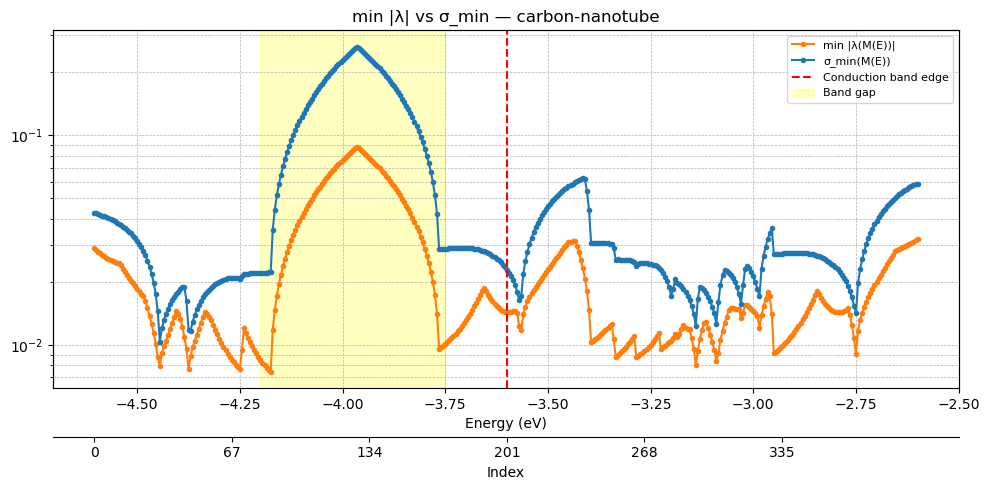

In [17]:
import matplotlib.ticker as ticker

min_abs_eig_arr = min_abs_eig_arr / 3

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(energies, min_abs_eig_arr, "o-", markersize=3, color="tab:orange", label="min |λ(M(E))|")
ax.plot(energies, min_singular_values, "o-", markersize=3, color="tab:blue", label="σ_min(M(E))")
ax.axvline(-3.6, color="red", linestyle="--", label="Conduction band edge")
ax.axvspan(-4.2, -3.75, color="yellow", alpha=0.25, label="Band gap")
ax.set_title(f"min |λ| vs σ_min — {name}")
ax.set_xlabel("Energy (eV)")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.yaxis.set_minor_locator(ticker.LogLocator(subs="all", numticks=20))
ax.yaxis.set_minor_formatter(ticker.NullFormatter())
ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.legend(fontsize=8)
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
step = max(1, len(energies) // 6)
ax2.set_xticks(energies[::step])
ax2.set_xticklabels(indices[::step])
ax2.set_xlabel("Index")
ax2.xaxis.set_label_position("bottom")
ax2.xaxis.tick_bottom()
ax2.spines["bottom"].set_position(("outward", 35))
plt.tight_layout()
plt.savefig(f"min_abs_eig_{name}.png", dpi=150, bbox_inches="tight")
plt.show()



In [18]:
################################# CHEAP CONDITION NUMBER ESTIMATE ###############################

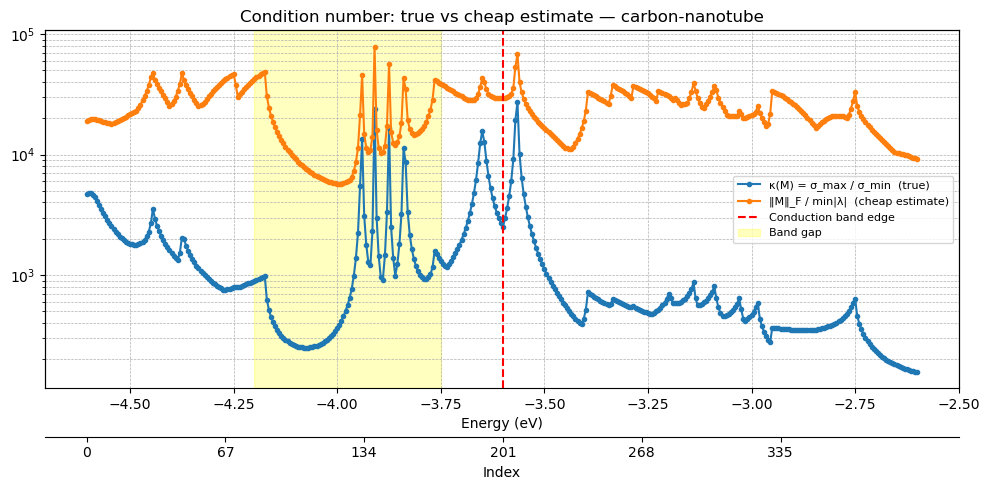

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(energies, condition_numbers,              "o-", markersize=3, color="tab:blue",
        label="κ(M) = σ_max / σ_min  (true)")
ax.plot(energies, upper_bound / min_abs_eig_arr, "o-", markersize=3, color="tab:orange",
        label="‖M‖_F / min|λ|  (cheap estimate)")
ax.axvline(-3.6, color="red", linestyle="--", label="Conduction band edge")
ax.axvspan(-4.2, -3.75, color="yellow", alpha=0.25, label="Band gap")
ax.set_title(f"Condition number: true vs cheap estimate — {name}")
ax.set_xlabel("Energy (eV)")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.yaxis.set_minor_locator(ticker.LogLocator(subs="all", numticks=20))
ax.yaxis.set_minor_formatter(ticker.NullFormatter())
ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.legend(fontsize=8)
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
step = max(1, len(energies) // 6)
ax2.set_xticks(energies[::step])
ax2.set_xticklabels(indices[::step])
ax2.set_xlabel("Index")
ax2.xaxis.set_label_position("bottom")
ax2.xaxis.tick_bottom()
ax2.spines["bottom"].set_position(("outward", 35))
plt.tight_layout()
plt.savefig(f"condition_estimate_true_cheap{name}.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
 #############################  EXPERIMENT SPARSE CSC FIRST ###########################

In [21]:
import scipy.sparse as sp
from pathlib import Path

def convert_and_save_sparse(data, output_folder, name, indices=None):
    """
    Convert dense matrix/matrices to CSC sparse format and save.
    
    Parameters
    ----------
    data         : np.ndarray or dict {idx: np.ndarray}
    output_folder: str or Path — relative to current directory
    name         : str — base filename (e.g. "M_E", "H", "S")
    indices      : list of indices (only needed if data is a dict)
    """
    output_folder = Path(output_folder)
    output_folder.mkdir(parents=True, exist_ok=True)

    if indices is not None:
        # dict of matrices indexed by energy
        for idx in indices:
            A_sp = sp.csc_matrix(data[idx])
            sp.save_npz(output_folder / f"{name}_{idx}.npz", A_sp)
        print(f"Saved {len(indices)} sparse matrices to {output_folder.resolve()}")
    else:
        # single matrix
        A_sp = sp.csc_matrix(data)
        sp.save_npz(output_folder / f"{name}.npz", A_sp)
        print(f"Saved {output_folder.resolve() / name}.npz")

In [22]:
folder2 = Path("sparse/carbon-nanotube")

# single matrices
convert_and_save_sparse(H, folder2, "H")
convert_and_save_sparse(S, folder2, "S")

# energy-dependent
convert_and_save_sparse(M,   folder2, "M_E",     indices=indices)
convert_and_save_sparse(Sig, folder2, "Sigma_E", indices=indices)


Saved /home/msc26f15/quatrex/qtbm_extract_matrix/jupyter/sparse/carbon-nanotube/H.npz
Saved /home/msc26f15/quatrex/qtbm_extract_matrix/jupyter/sparse/carbon-nanotube/S.npz
Saved 402 sparse matrices to /home/msc26f15/quatrex/qtbm_extract_matrix/jupyter/sparse/carbon-nanotube
Saved 402 sparse matrices to /home/msc26f15/quatrex/qtbm_extract_matrix/jupyter/sparse/carbon-nanotube


In [23]:
def min_abs_eig_sparse_csc(A_sp, tol=1e-6):
    try:
        vals = eigs(A_sp, k=1, sigma=0.0, which='LM',
                    tol=tol, return_eigenvectors=False)
        return np.abs(vals[0])
    except Exception:
        return np.min(np.abs(np.linalg.eigvals(A_sp.toarray())))


Text(0.5, 0, 'Index')

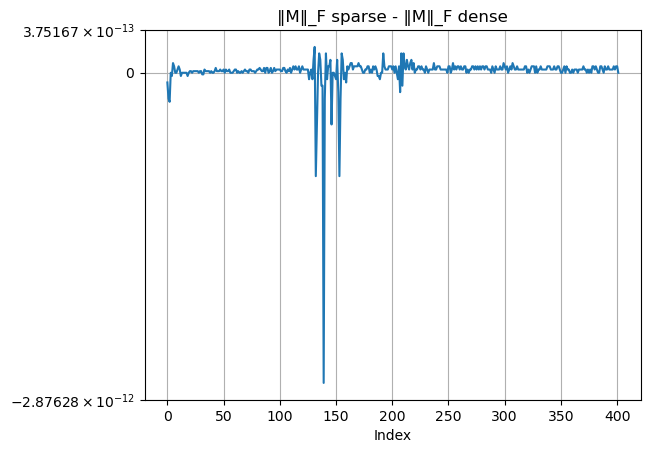

In [24]:
from scipy.sparse.linalg import norm as sparse_norm

def load_sparse(indices, folder):
    folder = Path(folder)
    return {idx: sp.load_npz(folder / f"M_E_{idx}.npz") for idx in indices}

M_sp = load_sparse(indices, folder2)

norm_M_sp = np.array([sparse_norm(M_sp[i], 'fro') for i in indices])
norm_M = np.array([np.linalg.norm(M[i], 'fro') for i in indices ])
plt.plot(indices, norm_M_sp - norm_M)
plt.yscale("symlog", linthresh=1e-10)
plt.grid(True, which="both")
plt.title("‖M‖_F sparse - ‖M‖_F dense")
plt.xlabel("Index")

In [25]:
min_abs_eig_arr_sp = np.array([min_abs_eig_sparse_csc(M_sp[i]) for i in indices]) / 3

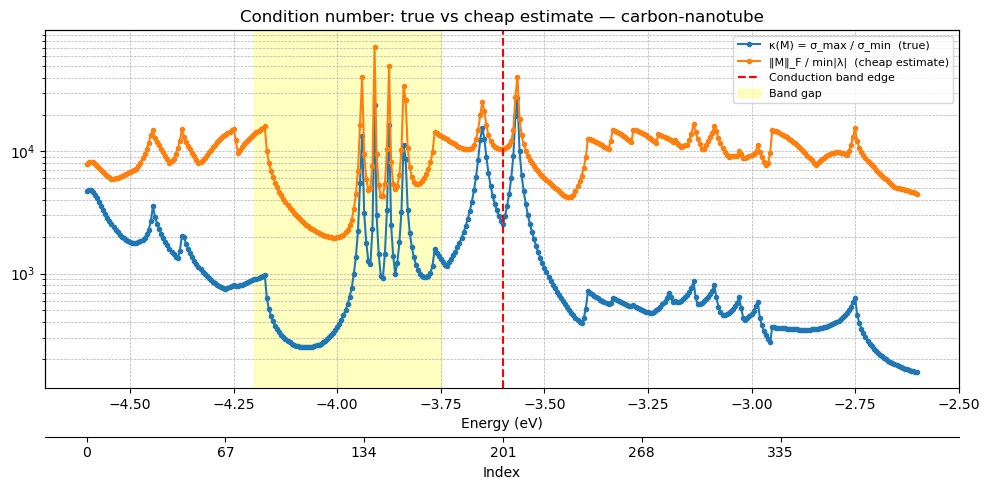

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(energies, condition_numbers,              "o-", markersize=3, color="tab:blue",
        label="κ(M) = σ_max / σ_min  (true)")
ax.plot(energies, norm_M_sp / min_abs_eig_arr_sp, "o-", markersize=3, color="tab:orange",
        label="‖M‖_F / min|λ|  (cheap estimate)")
ax.axvline(-3.6, color="red", linestyle="--", label="Conduction band edge")
ax.axvspan(-4.2, -3.75, color="yellow", alpha=0.25, label="Band gap")
ax.set_title(f"Condition number: true vs cheap estimate — {name}")
ax.set_xlabel("Energy (eV)")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.yaxis.set_minor_locator(ticker.LogLocator(subs="all", numticks=20))
ax.yaxis.set_minor_formatter(ticker.NullFormatter())
ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.legend(fontsize=8)
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
step = max(1, len(energies) // 6)
ax2.set_xticks(energies[::step])
ax2.set_xticklabels(indices[::step])
ax2.set_xlabel("Index")
ax2.xaxis.set_label_position("bottom")
ax2.xaxis.tick_bottom()
ax2.spines["bottom"].set_position(("outward", 35))
plt.tight_layout()
plt.savefig(f"condition_estimate_true_cheap_sparse{name}.png", dpi=150, bbox_inches="tight")
plt.show()

In [27]:
from scipy.sparse.linalg import svds, eigs

def condition_number_sparse(A_sp, tol=1e-6):
    # σ_max via Lanczos — cheap
    sigma_max = svds(A_sp, k=1, which='LM', return_singular_vectors=False)[0]
    
    # σ_min via shift-invert eigenvalue — cheap
    try:
        vals = eigs(A_sp, k=1, sigma=0.0, which='LM',
                    tol=tol, return_eigenvectors=False)
        sigma_min = np.abs(vals[0])
    except Exception:
        sigma_min = svds(A_sp, k=1, which='SM', return_singular_vectors=False)[0]
    
    return sigma_max / (sigma_min + 1e-300)

# test on one matrix
kappa_est = condition_number_sparse(M_sp[100])
print(f"κ_est(M(100)) = {kappa_est:.4e}")
print(f"κ_true(M(100)) = {condition_numbers[100]:.4e}")


κ_est(M(100)) = 2.6212e+02
κ_true(M(100)) = 2.6212e+02


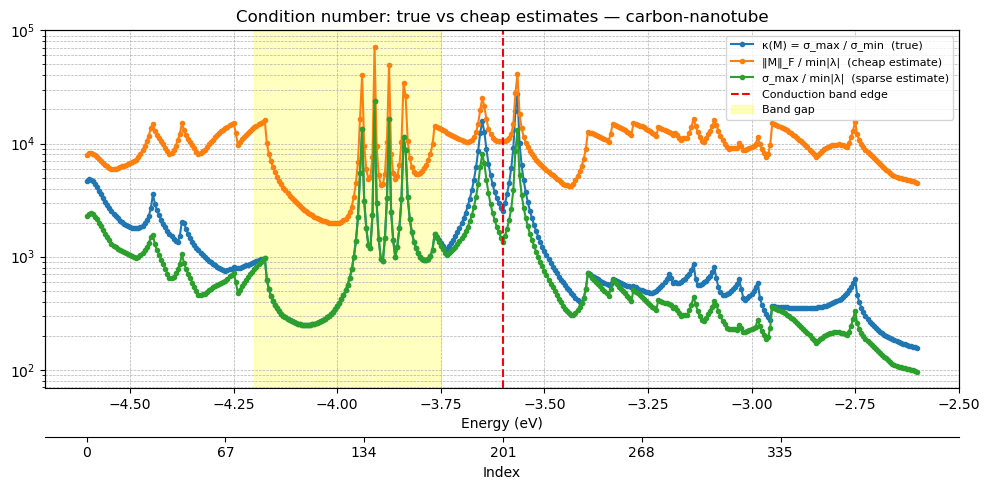

In [28]:
# Compute sparse condition number array
kappa_sparse_arr = np.array([condition_number_sparse(M_sp[i]) for i in indices])

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(energies, condition_numbers,              "o-", markersize=3, color="tab:blue",
        label="κ(M) = σ_max / σ_min  (true)")
ax.plot(energies, norm_M_sp / min_abs_eig_arr_sp, "o-", markersize=3, color="tab:orange",
        label="‖M‖_F / min|λ|  (cheap estimate)")
ax.plot(energies, kappa_sparse_arr,               "o-", markersize=3, color="tab:green",
        label="σ_max / min|λ|  (sparse estimate)")
ax.axvline(-3.6, color="red", linestyle="--", label="Conduction band edge")
ax.axvspan(-4.2, -3.75, color="yellow", alpha=0.25, label="Band gap")
ax.set_title(f"Condition number: true vs cheap estimates — {name}")
ax.set_xlabel("Energy (eV)")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.yaxis.set_minor_locator(ticker.LogLocator(subs="all", numticks=20))
ax.yaxis.set_minor_formatter(ticker.NullFormatter())
ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.legend(fontsize=8)
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
step = max(1, len(energies) // 6)
ax2.set_xticks(energies[::step])
ax2.set_xticklabels(indices[::step])
ax2.set_xlabel("Index")
ax2.xaxis.set_label_position("bottom")
ax2.xaxis.tick_bottom()
ax2.spines["bottom"].set_position(("outward", 35))
plt.tight_layout()
plt.savefig(f"condition_estimate_true_cheap_sparse_scipy{name}.png", dpi=150, bbox_inches="tight")
plt.show()